# North Carolina Social-Economic Exposome Knowledge Graph

This notebook builds a knowledge graph for North Carolina's social-economic exposome using open-source databases.

## Overview

This notebook builds a comprehensive knowledge graph for North Carolina's social-economic exposome using **real data** from:

- **US Census Bureau API**: Demographics, income, education, employment (2022 or most recent)
- **County Health Rankings 2025**: Comprehensive health outcomes, behaviors, and environmental factors
- **CDC PLACES** (fallback): Health outcomes and risk factors when CHR is not available

### Key Features:
- Automated data fetching from Census API (tries 2022, falls back to 2021)
- Integration of County Health Rankings 2025 complete dataset
- Multi-dimensional knowledge graph with real indicators
- Advanced analytics and correlations
- Multiple visualization types
- Export to RDF N-Triples, JSON, CSV formats

### Data Sources Priority:
1. **Primary**: Census 2022 + CHR 2025 (most comprehensive and recent)
2. **Fallback**: Census 2021 + CDC PLACES (if CHR data not available)

### Quick Start:
1. Ensure `chr_2025_nc_complete.csv` is in the working directory
2. Run all cells in order (Kernel → Restart & Run All)
3. The notebook will automatically fetch Census data and integrate CHR 2025 health data
4. All data is real and sourced from official databases

Let's begin!

## 1. Setup and Dependencies

In [1]:
# Install required packages
# !pip install networkx pandas numpy matplotlib seaborn rdflib requests census beautifulsoup4 plotly

In [2]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import json
from collections import defaultdict
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## 2. Data Sources Configuration

We use the following open-source databases:
- **US Census Bureau API**: Demographics, income, education, employment (real data)
- **CDC PLACES**: Health outcomes and risk factors (real data when available)

Note: Environmental indicators (air quality, PM2.5, etc.) would require EPA EJScreen API integration and are not included in this version.

In [3]:
# Data source URLs
DATA_SOURCES = {
    'census': 'https://api.census.gov/data',
    'cdc_places': 'https://data.cdc.gov/resource/cwsq-ngmh.json',
    'epa_ejscreen': 'https://gaftp.epa.gov/EJSCREEN/',
}

# NC FIPS code
NC_FIPS = '37'

# NC Counties (top counties for demo)
NC_COUNTIES = {
    '37119': 'Mecklenburg',
    '37183': 'Wake',
    '37081': 'Guilford',
    '37063': 'Durham',
    '37067': 'Forsyth',
    '37129': 'New Hanover',
    '37025': 'Cabarrus',
    '37035': 'Catawba',
    '37071': 'Gaston',
    '37179': 'Union'
}

In [4]:
# Census API Key
CENSUS_API_KEY = '06923f0e932771fcf5f0d4babb9bf866508659dc'
print("Census API key configured")

Census API key configured


## 3. Knowledge Graph Schema Design

### Node Types:
- **Location**: County, City, Census Tract
- **Indicator**: Social-economic and environmental indicators
- **Category**: Grouping of related indicators
- **Measurement**: Actual values

### Edge Types:
- **LOCATED_IN**: Geographic hierarchy
- **HAS_INDICATOR**: Location has indicator measurement
- **BELONGS_TO**: Indicator belongs to category
- **CORRELATES_WITH**: Statistical correlation between indicators

In [5]:
class ExposomeKnowledgeGraph:
    """Triple-based Knowledge Graph for Social-Economic Exposome
    
    Inspired by ROBOKOP's reasoning capabilities, adapted for social determinants of health.
    All data stored as triples with provenance and confidence scoring.
    """
    
    def __init__(self):
        # Triples now include provenance and confidence
        self.triples = []  # List of dicts with: subject, predicate, object, provenance, confidence
        
    def add_triple(self, subject, predicate, obj, provenance=None, confidence=1.0):
        """Add a triple with evidence tracking (ROBOKOP-inspired)"""
        self.triples.append({
            'subject': subject,
            'predicate': predicate,
            'object': obj,
            'provenance': provenance or {'source': 'inferred'},
            'confidence': confidence
        })
        
    def add_location(self, location_id, location_type, name, properties=None):
        """Add a location with provenance"""
        prov = {'source': 'US Census Bureau', 'year': 2021}
        self.add_triple(location_id, 'rdf:type', 'Location', prov, 1.0)
        self.add_triple(location_id, 'locationType', location_type, prov, 1.0)
        self.add_triple(location_id, 'name', name, prov, 1.0)
        if properties:
            for key, value in properties.items():
                self.add_triple(location_id, key, value, prov, 1.0)
                
    def add_indicator(self, indicator_id, category, name, description=None):
        """Add an indicator with provenance"""
        prov = {'source': 'schema_definition'}
        self.add_triple(indicator_id, 'rdf:type', 'Indicator', prov, 1.0)
        self.add_triple(indicator_id, 'category', category, prov, 1.0)
        self.add_triple(indicator_id, 'name', name, prov, 1.0)
        if description:
            self.add_triple(indicator_id, 'description', description, prov, 1.0)
            
    def add_measurement(self, location_id, indicator_id, value, year=None, unit=None, source='Census'):
        """Add measurement with data source tracking"""
        measurement_id = f"m_{location_id}_{indicator_id}"
        
        # Determine confidence based on source
        confidence_map = {
            'Census': 0.95,
            'CDC': 0.90,
            'EPA': 0.85,
            'sample': 0.50
        }
        confidence = confidence_map.get(source, 0.75)
        
        prov = {
            'source': source,
            'year': year or 2021,
            'method': 'ACS 5-year estimate' if source == 'Census' else 'official_data'
        }
        
        self.add_triple(measurement_id, 'rdf:type', 'Measurement', prov, confidence)
        self.add_triple(measurement_id, 'location', location_id, prov, confidence)
        self.add_triple(measurement_id, 'indicator', indicator_id, prov, confidence)
        self.add_triple(measurement_id, 'value', value, prov, confidence)
        if unit:
            self.add_triple(measurement_id, 'unit', unit, prov, confidence)
            
    def add_correlation(self, indicator1, indicator2, correlation, p_value=None, n_samples=100):
        """Add correlation with statistical confidence (ROBOKOP-style evidence)"""
        corr_id = f"corr_{indicator1}_{indicator2}"
        
        # Calculate confidence based on statistical significance
        if p_value is not None:
            if p_value < 0.001:
                confidence = 0.95
            elif p_value < 0.01:
                confidence = 0.85
            elif p_value < 0.05:
                confidence = 0.75
            else:
                confidence = 0.50
        else:
            confidence = 0.70
            
        # Boost confidence for strong correlations and large samples
        if abs(correlation) > 0.7:
            confidence = min(1.0, confidence + 0.05)
        if n_samples > 100:
            confidence = min(1.0, confidence + 0.03)
            
        prov = {
            'source': 'statistical_analysis',
            'method': 'pearson_correlation',
            'p_value': p_value,
            'n_samples': n_samples
        }
        
        self.add_triple(corr_id, 'rdf:type', 'Correlation', prov, confidence)
        self.add_triple(corr_id, 'indicator1', indicator1, prov, confidence)
        self.add_triple(corr_id, 'indicator2', indicator2, prov, confidence)
        self.add_triple(corr_id, 'value', correlation, prov, confidence)
        if p_value:
            self.add_triple(corr_id, 'pValue', p_value, prov, confidence)
            
    def query(self, subject=None, predicate=None, obj=None, min_confidence=0.0):
        """Query triples with confidence filtering"""
        results = []
        for triple in self.triples:
            if (subject is None or triple['subject'] == subject) and \
               (predicate is None or triple['predicate'] == predicate) and \
               (obj is None or triple['object'] == obj) and \
               triple['confidence'] >= min_confidence:
                results.append(triple)
        return results
    
    def query_path(self, start_entity, end_entity, max_hops=3):
        """Find paths between entities (ROBOKOP-inspired pathway reasoning)"""
        paths = []
        
        def find_paths_recursive(current, target, path, visited, hops):
            if hops > max_hops:
                return
            if current == target and len(path) > 1:
                path_confidence = min([step['confidence'] for step in path])
                paths.append({
                    'path': path[:],
                    'confidence': path_confidence,
                    'hops': len(path) - 1
                })
                return
                
            visited.add(current)
            outgoing = self.query(subject=current)
            for triple in outgoing:
                next_node = triple['object']
                if next_node not in visited and not isinstance(next_node, (int, float)):
                    path.append(triple)
                    find_paths_recursive(next_node, target, path, visited.copy(), hops + 1)
                    path.pop()
        
        find_paths_recursive(start_entity, end_entity, [], set(), 0)
        paths.sort(key=lambda x: x['confidence'], reverse=True)
        return paths
    
    def find_mechanistic_pathway(self, social_indicator, health_outcome):
        """Find social-economic mechanistic pathways to health outcomes"""
        paths = self.query_path(social_indicator, health_outcome, max_hops=3)
        mechanistic_paths = []
        for path_data in paths:
            path = path_data['path']
            has_correlation = any(t['predicate'] in ['indicator1', 'indicator2'] for t in path)
            if has_correlation:
                mechanistic_paths.append(path_data)
        return mechanistic_paths
    
    def get_location_profile(self, location_id):
        """Get all measurements for a location with provenance"""
        profile = {}
        measurements = self.query(predicate='location', obj=location_id)
        
        for m_triple in measurements:
            m_id = m_triple['subject']
            indicator_triples = self.query(subject=m_id, predicate='indicator')
            if not indicator_triples:
                continue
            indicator_id = indicator_triples[0]['object']
            name_triples = self.query(subject=indicator_id, predicate='name')
            indicator_name = name_triples[0]['object'] if name_triples else indicator_id
            value_triples = self.query(subject=m_id, predicate='value')
            value = value_triples[0]['object'] if value_triples else None
            unit_triples = self.query(subject=m_id, predicate='unit')
            unit = unit_triples[0]['object'] if unit_triples else ''
            
            profile[indicator_name] = {
                'value': value,
                'unit': unit,
                'source': m_triple['provenance'].get('source', 'unknown'),
                'confidence': m_triple['confidence']
            }
        return profile
    
    def get_statistics(self):
        """Get knowledge graph statistics"""
        stats = {
            'total_triples': len(self.triples),
            'locations': len(self.query(predicate='rdf:type', obj='Location')),
            'indicators': len(self.query(predicate='rdf:type', obj='Indicator')),
            'measurements': len(self.query(predicate='rdf:type', obj='Measurement')),
            'correlations': len(self.query(predicate='rdf:type', obj='Correlation')),
            'high_confidence_triples': len([t for t in self.triples if t['confidence'] >= 0.9]),
        }
        return stats
    
    def export_to_ntriples(self, filename='knowledge_graph.nt'):
        """Export to N-Triples RDF format with provenance comments"""
        with open(filename, 'w', encoding='utf-8') as f:
            for triple in self.triples:
                s, p, o = triple['subject'], triple['predicate'], triple['object']
                if isinstance(o, (int, float)):
                    o_str = f'"{o}"^^<http://www.w3.org/2001/XMLSchema#decimal>'
                elif isinstance(o, str):
                    o_str = f'"{o}"'
                else:
                    o_str = f'"{str(o)}"'
                prov = triple['provenance']
                conf = triple['confidence']
                f.write(f'<{s}> <{p}> {o_str} .\n')
                f.write(f'# Source: {prov.get("source", "unknown")}, Confidence: {conf:.2f}\n')
        return filename
    
    def export_to_csv(self, filename='knowledge_graph.csv'):
        """Export triples to CSV with provenance"""
        import pandas as pd
        rows = []
        for t in self.triples:
            rows.append({
                'subject': t['subject'],
                'predicate': t['predicate'],
                'object': t['object'],
                'source': t['provenance'].get('source', 'unknown'),
                'confidence': t['confidence']
            })
        df = pd.DataFrame(rows)
        df.to_csv(filename, index=False)
        return df

# Initialize knowledge graph
kg = ExposomeKnowledgeGraph()
print("Triple-based Knowledge Graph initialized (ROBOKOP-inspired)")
print("Features: Provenance tracking, Confidence scoring, Path reasoning")

Triple-based Knowledge Graph initialized (ROBOKOP-inspired)
Features: Provenance tracking, Confidence scoring, Path reasoning


In [6]:
def fetch_census_data(variables, year=2022, api_key=CENSUS_API_KEY):
    """Fetch Census data for NC counties
    
    Common variables:
    - B01003_001E: Total Population
    - B19013_001E: Median Household Income
    - B15003_022E: Bachelor's degree
    - B15003_001E: Total population 25+ (for education denominator)
    - B23025_005E: Unemployed
    - B23025_003E: Labor force (for unemployment denominator)
    - B17001_002E: Income below poverty level
    - B17001_001E: Total for poverty determination
    """
    base_url = f"https://api.census.gov/data/{year}/acs/acs5"
    
    params = {
        'get': ','.join(['NAME'] + variables),
        'for': 'county:*',
        'in': f'state:{NC_FIPS}',
        'key': api_key
    }
    
    try:
        response = requests.get(base_url, params=params, timeout=10)
        if response.status_code == 200:
            data = response.json()
            df = pd.DataFrame(data[1:], columns=data[0])
            # Convert numeric columns
            for col in df.columns:
                if col not in ['NAME', 'state', 'county']:
                    df[col] = pd.to_numeric(df[col], errors='coerce')
            return df
        else:
            print(f"Error fetching census data for {year}: {response.status_code}")
            print(f"Response: {response.text}")
            # Try previous year
            if year > 2021:
                print(f"Trying {year-1} data instead...")
                return fetch_census_data(variables, year-1, api_key)
            return None
    except Exception as e:
        print(f"Exception fetching census data: {e}")
        return None

def load_chr_data(filepath='chr_2025_nc_complete.csv'):
    """Load County Health Rankings 2025 data"""
    try:
        df = pd.read_csv(filepath)
        print(f"✓ Loaded CHR 2025 data: {len(df)} counties")
        
        # Ensure fips is string with proper format
        if 'fips' in df.columns:
            df['fips'] = df['fips'].astype(str).str.zfill(5)
        
        # Show available columns
        health_cols = [col for col in df.columns if col not in ['county', 'fips']]
        print(f"  Available health indicators: {len(health_cols)}")
        
        # Show data completeness
        for col in health_cols:
            non_null = df[col].notna().sum()
            pct = non_null / len(df) * 100 if len(df) > 0 else 0
            if pct >= 50:  # Only show indicators with >= 50% data
                print(f"    {col}: {pct:.1f}% complete")
        
        return df
    except FileNotFoundError:
        print(f"⚠ CHR data file not found: {filepath}")
        return None
    except Exception as e:
        print(f"⚠ Error loading CHR data: {e}")
        return None

def fetch_cdc_places_data(state='NC', year=2023):
    """Fetch CDC PLACES health data for NC
    
    Common measures:
    - CASTHMA: Current asthma
    - BPHIGH: High blood pressure
    - CHD: Coronary heart disease
    - DIABETES: Diabetes
    - OBESITY: Obesity
    - MHLTH: Mental health not good
    - ACCESS2: Lack of health insurance
    """
    url = 'https://data.cdc.gov/resource/swc5-untb.json'
    
    params = {
        '$where': f"stateabbr='{state}' AND year='{year}'",
        '$limit': 50000,
    }
    
    try:
        response = requests.get(url, params=params, timeout=30)
        if response.status_code == 200:
            df = pd.DataFrame(response.json())
            return df
        else:
            print(f"Error fetching CDC data: {response.status_code}")
            return None
    except Exception as e:
        print(f"Exception fetching CDC data: {e}")
        return None

print("Data collection functions defined")

Data collection functions defined


## 4A. Fetch Real Census Data

Now let's fetch real Census data using the API key.

In [7]:
# Fetch real Census data (trying to get most recent year available)
print("Fetching Census data...")
print("Attempting to fetch 2022 data (most recent year typically available)...")

census_variables = [
    'B01003_001E',  # Total Population
    'B19013_001E',  # Median Household Income
    'B17001_002E',  # Income below poverty level
    'B17001_001E',  # Total for poverty determination
    'B23025_005E',  # Unemployed
    'B23025_003E',  # Labor force
    'B15003_022E',  # Bachelor's degree
    'B15003_023E',  # Master's degree
    'B15003_001E',  # Total population 25+
]

df_census = fetch_census_data(census_variables, year=2022)
census_year = 2022

if df_census is None:
    print("Failed to fetch 2022 data, falling back to 2021...")
    df_census = fetch_census_data(census_variables, year=2021)
    census_year = 2021

if df_census is not None:
    print(f"✓ Successfully fetched Census data for {len(df_census)} NC counties (year: {census_year})")
    
    # Create FIPS code
    df_census['fips'] = df_census['state'] + df_census['county']
    
    # Calculate derived indicators
    df_census['poverty_rate'] = (df_census['B17001_002E'] / df_census['B17001_001E'] * 100)
    df_census['unemployment_rate'] = (df_census['B23025_005E'] / df_census['B23025_003E'] * 100)
    df_census['education_bachelor_pct'] = ((df_census['B15003_022E'] + df_census['B15003_023E']) / 
                                           df_census['B15003_001E'] * 100)
    
    # Rename columns for clarity
    df_census = df_census.rename(columns={
        'NAME': 'county_name',
        'B01003_001E': 'population',
        'B19013_001E': 'median_income'
    })
    
    # Extract just county name (remove ", North Carolina")
    df_census['county'] = df_census['county_name'].str.replace(' County, North Carolina', '')
    
    # Select relevant columns
    df_census_clean = df_census[['fips', 'county', 'population', 'median_income', 
                                  'poverty_rate', 'unemployment_rate', 'education_bachelor_pct']].copy()
    
    print(f"\nSample of Census data (Year: {census_year}):")
    display(df_census_clean.head(10))
else:
    print("✗ Failed to fetch Census data.")
    census_year = None

Fetching Census data...
Attempting to fetch 2022 data (most recent year typically available)...
✓ Successfully fetched Census data for 100 NC counties (year: 2022)

Sample of Census data (Year: 2022):


,fips,county,population,median_income,poverty_rate,unemployment_rate,education_bachelor_pct
0,37001,Alamance,171779,60866,14.217678,4.990707,25.169339
1,37003,Alexander,36505,62764,12.249380,5.583035,14.571797
2,37005,Alleghany,10989,42115,19.549632,5.319836,19.511048
3,37007,Anson,22200,42000,19.347342,6.420150,10.968968
4,37009,Ashe,26759,49176,14.117202,5.097658,19.056429
5,37011,Avery,17679,53513,11.220472,5.006382,19.238403
6,37013,Beaufort,44711,56081,17.051172,5.599805,17.464978
7,37015,Bertie,17818,41652,21.414586,6.395608,16.089385
8,37017,Bladen,29807,40476,24.419079,5.481699,18.302338
9,37019,Brunswick,139721,71193,9.076084,4.995625,29.543585


## 4B. Fetch Real CDC PLACES Data

Fetch health outcome data from CDC PLACES database.

## 4B. Load County Health Rankings 2025 Data

Load comprehensive health data from County Health Rankings 2025.

In [8]:
# Load County Health Rankings 2025 data
print("Loading County Health Rankings 2025 data...")

df_chr = load_chr_data('chr_2025_nc_complete.csv')

if df_chr is not None:
    # Standardize county names for merging
    df_chr['county'] = df_chr['county'].str.strip()
    
    print(f"\nSample of CHR 2025 data:")
    # Show columns that have good data
    sample_cols = ['county', 'fips']
    for col in ['obesity_pct', 'diabetes_pct', 'mental_health_days', 'uninsured_pct']:
        if col in df_chr.columns and df_chr[col].notna().sum() > 50:
            sample_cols.append(col)
    
    if len(sample_cols) > 2:
        display(df_chr[sample_cols].head(10))
    else:
        display(df_chr[['county', 'fips']].head(10))
else:
    print("⚠ CHR 2025 data not available.")

Loading County Health Rankings 2025 data...
✓ Loaded CHR 2025 data: 100 counties
  Available health indicators: 11
    mental_health_days: 100.0% complete
    physical_health_days: 100.0% complete
    uninsured_pct: 100.0% complete
    unemployment_pct: 100.0% complete
    some_college_pct: 100.0% complete
    child_poverty_pct: 100.0% complete
    pm25: 99.0% complete
    obesity_pct: 100.0% complete
    diabetes_pct: 100.0% complete
    physical_inactivity_pct: 100.0% complete
    excessive_drinking_pct: 100.0% complete

Sample of CHR 2025 data:


,county,fips,obesity_pct,diabetes_pct,mental_health_days,uninsured_pct
0,Alamance,37001,38.0,11.3,5.113251,12.580197
1,Alexander,37003,33.8,9.7,5.266819,11.926507
2,Alleghany,37005,36.6,11.1,5.549751,17.302539
3,Anson,37007,43.1,13.9,5.429053,12.467217
4,Ashe,37009,33.9,9.6,5.262817,13.603904
5,Avery,37011,33.1,10.1,5.226336,15.698793
6,Beaufort,37013,38.3,11.5,5.133520,12.207784
7,Bertie,37015,43.5,14.9,5.329808,11.694703
8,Bladen,37017,38.6,12.7,5.511453,13.971539
9,Brunswick,37019,30.9,9.2,4.955653,10.250946


In [9]:
# Fetch real CDC PLACES data
print("Fetching CDC PLACES health data...")

df_cdc = fetch_cdc_places_data(state='NC', year='2021')  # Use 2021 to match Census data

if df_cdc is not None and len(df_cdc) > 0:
    print(f"✓ Successfully fetched CDC PLACES data: {len(df_cdc)} records")
    
    # CDC PLACES returns county names WITHOUT "County" suffix in locationname
    # The data is already county-level when stateabbr='NC' and year is specified
    print(f"\nSample location names:")
    print(df_cdc['locationname'].head(10).tolist())
    
    df_cdc_county = df_cdc.copy()
    print(f"  County-level records: {len(df_cdc_county)}")
    
    if len(df_cdc_county) > 0:
        # Key health measures to extract
        health_measures = {
            'OBESITY': 'obesity_pct',
            'DIABETES': 'diabetes_pct',
            'CASTHMA': 'asthma_pct',
            'MHLTH': 'mental_health_pct',
            'BPHIGH': 'high_bp_pct',
            'ACCESS2': 'no_insurance_pct'
        }
        
        # Pivot the data to get one row per county
        health_data = []
        for county in df_cdc_county['locationname'].unique():
            county_data = df_cdc_county[df_cdc_county['locationname'] == county]
            row = {
                'county': county,  # County name already without " County" suffix
                'countyfips': county_data['locationid'].iloc[0] if len(county_data) > 0 else None
            }
            
            for measure_id, col_name in health_measures.items():
                measure_data = county_data[county_data['measureid'] == measure_id]
                if len(measure_data) > 0:
                    # Use crude prevalence
                    value = measure_data['data_value'].iloc[0]
                    row[col_name] = float(value) if pd.notna(value) else None
            
            health_data.append(row)
        
        df_health = pd.DataFrame(health_data)
        
        # Rename fips column
        df_health = df_health.rename(columns={'countyfips': 'fips'})
        
        print(f"\n✓ Processed health data for {len(df_health)} counties")
        print(f"Available health indicators: {list(health_measures.values())}")
        print("\nSample of health data:")
        display(df_health.head(10))
    else:
        print("⚠ No county-level data found in CDC PLACES response")
        df_health = pd.DataFrame()
else:
    print("✗ Failed to fetch CDC PLACES data. Will use Census data only.")
    df_health = None

Fetching CDC PLACES health data...
✓ Successfully fetched CDC PLACES data: 800 records

Sample location names:
['Harnett', 'Haywood', 'Pamlico', 'McDowell', 'Robeson', 'Jackson', 'Rutherford', 'Ashe', 'Wilson', 'Catawba']
  County-level records: 800

✓ Processed health data for 100 counties
Available health indicators: ['obesity_pct', 'diabetes_pct', 'asthma_pct', 'mental_health_pct', 'high_bp_pct', 'no_insurance_pct']

Sample of health data:


,county,fips,high_bp_pct
0,Harnett,37085,35.0
1,Haywood,37087,39.0
2,Pamlico,37137,43.7
3,McDowell,37111,36.0
4,Robeson,37155,42.4
5,Jackson,37099,32.6
6,Rutherford,37161,39.4
7,Ashe,37009,30.0
8,Wilson,37195,37.0
9,Catawba,37035,35.4


## 4C. Combine Real Data with Sample Environmental Data

Merge Census and CDC data, and add sample environmental indicators (which would come from EPA EJScreen in a full implementation).

In [10]:
# Combine Census data with CHR 2025 health data
print("Combining data sources...")
print("=" * 80)

# Check if we have Census data
if 'df_census_clean' in locals() and df_census_clean is not None:
    # Start with Census data
    df_exposome = df_census_clean.copy()
    print(f"✓ Using Census {census_year} data: {len(df_exposome)} counties")
    
    # Prioritize CHR 2025 data for health indicators (more comprehensive and recent)
    if 'df_chr' in locals() and df_chr is not None and len(df_chr) > 0:
        print(f"\n📊 Merging CHR 2025 health data...")
        
        # Merge CHR data
        df_exposome = df_exposome.merge(df_chr, on='fips', how='left', suffixes=('', '_chr'))
        
        # Remove duplicate county column if it exists
        if 'county_chr' in df_exposome.columns:
            df_exposome = df_exposome.drop('county_chr', axis=1)
        
        # Check data completeness for key health indicators
        health_indicators = ['obesity_pct', 'diabetes_pct', 'mental_health_days', 'physical_health_days', 
                           'uninsured_pct', 'pm25']
        
        complete_indicators = []
        for ind in health_indicators:
            if ind in df_exposome.columns:
                complete_count = df_exposome[ind].notna().sum()
                pct_complete = complete_count / len(df_exposome) * 100
                if complete_count > 0:
                    complete_indicators.append(ind)
                    print(f"    {ind}: {complete_count}/{len(df_exposome)} counties ({pct_complete:.1f}%)")
        
        print(f"\n✓ Merged CHR 2025 data: {len(complete_indicators)} health indicators available")
    
    # Fall back to CDC PLACES data if CHR is not available
    elif 'df_health' in locals() and df_health is not None and len(df_health) > 0:
        print(f"\n📊 CHR 2025 data not available, using CDC PLACES data...")
        df_exposome = df_exposome.merge(df_health, on='fips', how='left', suffixes=('', '_health'))
        
        # Remove duplicate county column if it exists
        if 'county_health' in df_exposome.columns:
            df_exposome = df_exposome.drop('county_health', axis=1)
        
        # Check how many counties have health data
        health_complete = df_exposome[['obesity_pct']].notna().sum()[0] if 'obesity_pct' in df_exposome.columns else 0
        print(f"✓ Merged CDC health data: {health_complete} counties with health indicators")
    else:
        print("\n⚠ No health data available - only Census socioeconomic data will be used")
    
    print(f"\n" + "=" * 80)
    print(f"✓ Final dataset created: {len(df_exposome)} counties × {len(df_exposome.columns)} indicators")
    print(f"\nData sources:")
    print(f"  - Census {census_year if 'census_year' in locals() else 2021}: Demographics, income, poverty, unemployment, education")
    
    if 'df_chr' in locals() and df_chr is not None:
        print(f"  - CHR 2025: Health outcomes, behaviors, and environmental factors")
    elif 'obesity_pct' in df_exposome.columns and df_exposome['obesity_pct'].notna().sum() > 0:
        print(f"  - CDC PLACES: Health outcomes (limited)")
    
    print(f"\nSample of combined data:")
    sample_cols = ['county', 'population', 'median_income', 'poverty_rate']
    if 'obesity_pct' in df_exposome.columns and df_exposome['obesity_pct'].notna().sum() > 10:
        sample_cols.append('obesity_pct')
    if 'diabetes_pct' in df_exposome.columns and df_exposome['diabetes_pct'].notna().sum() > 10:
        sample_cols.append('diabetes_pct')
    
    display(df_exposome[sample_cols].head())
else:
    print("⚠ No Census data available.")
    df_exposome = None

Combining data sources...
✓ Using Census 2022 data: 100 counties

📊 Merging CHR 2025 health data...
    obesity_pct: 100/100 counties (100.0%)
    diabetes_pct: 100/100 counties (100.0%)
    mental_health_days: 100/100 counties (100.0%)
    physical_health_days: 100/100 counties (100.0%)
    uninsured_pct: 100/100 counties (100.0%)
    pm25: 99/100 counties (99.0%)

✓ Merged CHR 2025 data: 6 health indicators available

✓ Final dataset created: 100 counties × 18 indicators

Data sources:
  - Census 2022: Demographics, income, poverty, unemployment, education
  - CHR 2025: Health outcomes, behaviors, and environmental factors

Sample of combined data:


,county,population,median_income,poverty_rate,obesity_pct,diabetes_pct
0,Alamance,171779,60866,14.217678,38.0,11.3
1,Alexander,36505,62764,12.249380,33.8,9.7
2,Alleghany,10989,42115,19.549632,36.6,11.1
3,Anson,22200,42000,19.347342,43.1,13.9
4,Ashe,26759,49176,14.117202,33.9,9.6


In [11]:
# Build Knowledge Graph with integrated data
print("Building knowledge graph with integrated data...")
print("=" * 80)

# Define indicator categories based on available data
INDICATOR_CATEGORIES = {
    'Demographics': ['population'],
    'Economic': ['median_income', 'poverty_rate', 'unemployment_rate', 'child_poverty_pct'],
    'Education': ['education_bachelor_pct', 'high_school_completion_pct', 'some_college_pct'],
}

# Add health indicators if they exist in the dataset
health_indicators_available = []
for health_ind in ['obesity_pct', 'diabetes_pct', 'asthma_pct', 'smoking_pct', 'physical_inactivity_pct', 
                   'excessive_drinking_pct', 'mental_health_days', 'physical_health_days']:
    if health_ind in df_exposome.columns and df_exposome[health_ind].notna().sum() > 0:
        health_indicators_available.append(health_ind)

if len(health_indicators_available) > 0:
    INDICATOR_CATEGORIES['Health'] = health_indicators_available

# Add access indicators
access_indicators_available = []
for access_ind in ['uninsured_pct', 'no_insurance_pct', 'primary_care_ratio']:
    if access_ind in df_exposome.columns and df_exposome[access_ind].notna().sum() > 0:
        access_indicators_available.append(access_ind)

if len(access_indicators_available) > 0:
    INDICATOR_CATEGORIES['Access'] = access_indicators_available

# Add environment indicators (PM2.5 from CHR)
env_indicators_available = []
for env_ind in ['pm25', 'air_quality_index']:
    if env_ind in df_exposome.columns and df_exposome[env_ind].notna().sum() > 0:
        env_indicators_available.append(env_ind)

if len(env_indicators_available) > 0:
    INDICATOR_CATEGORIES['Environment'] = env_indicators_available

# Comprehensive indicator metadata
indicator_metadata = {
    # Demographics
    'population': ('Total Population', 'count', 'Census'),
    
    # Economic
    'median_income': ('Median Household Income', 'USD', 'Census'),
    'poverty_rate': ('Poverty Rate', 'percent', 'Census'),
    'unemployment_rate': ('Unemployment Rate', 'percent', 'Census'),
    'unemployment_pct': ('Unemployment Rate', 'percent', 'CHR'),
    'child_poverty_pct': ('Child Poverty Rate', 'percent', 'CHR'),
    
    # Education
    'education_bachelor_pct': ('Bachelor\'s Degree or Higher', 'percent', 'Census'),
    'high_school_completion_pct': ('High School Completion', 'percent', 'CHR'),
    'some_college_pct': ('Some College', 'percent', 'CHR'),
    
    # Health - Outcomes
    'obesity_pct': ('Adult Obesity Prevalence', 'percent', 'CHR'),
    'diabetes_pct': ('Diabetes Prevalence', 'percent', 'CHR'),
    'asthma_pct': ('Asthma Prevalence', 'percent', 'CHR'),
    'mental_health_days': ('Poor Mental Health Days', 'days', 'CHR'),
    'physical_health_days': ('Poor Physical Health Days', 'days', 'CHR'),
    
    # Health - Behaviors
    'smoking_pct': ('Adult Smoking', 'percent', 'CHR'),
    'physical_inactivity_pct': ('Physical Inactivity', 'percent', 'CHR'),
    'excessive_drinking_pct': ('Excessive Drinking', 'percent', 'CHR'),
    
    # Access
    'uninsured_pct': ('Uninsured Rate', 'percent', 'CHR'),
    'no_insurance_pct': ('No Health Insurance', 'percent', 'CDC'),
    'primary_care_ratio': ('Primary Care Physician Ratio', 'ratio', 'CHR'),
    
    # Environment
    'pm25': ('PM2.5 Concentration', 'μg/m³', 'CHR'),
    'air_quality_index': ('Air Quality Index', 'index', 'EPA'),
}

# Only keep metadata for indicators that exist in our dataset
indicator_metadata = {k: v for k, v in indicator_metadata.items() if k in df_exposome.columns}

# Initialize new knowledge graph
kg = ExposomeKnowledgeGraph()

# Add locations to knowledge graph
data_year = census_year if 'census_year' in locals() else 2021
for _, row in df_exposome.iterrows():
    kg.add_location(
        location_id=row['fips'],
        location_type='county',
        name=row['county'],
        properties={'state': 'North Carolina', 'population': row['population'] if pd.notna(row['population']) else 0}
    )

# Add indicators to knowledge graph
for category, indicators in INDICATOR_CATEGORIES.items():
    for indicator in indicators:
        if indicator in indicator_metadata:
            name, unit, source = indicator_metadata[indicator]
            kg.add_indicator(
                indicator_id=indicator,
                category=category,
                name=name,
                description=f"{category} indicator: {name} (Source: {source})"
            )

# Add measurements
measurement_count = 0
for _, row in df_exposome.iterrows():
    for indicator in indicator_metadata.keys():
        if indicator in df_exposome.columns and pd.notna(row[indicator]):
            name, unit, source = indicator_metadata[indicator]
            # Determine year based on source
            year = 2025 if source == 'CHR' else data_year
            kg.add_measurement(
                location_id=row['fips'],
                indicator_id=indicator,
                value=row[indicator],
                year=year,
                unit=unit,
                source=source
            )
            measurement_count += 1

print(f"✓ Added {measurement_count} measurements to knowledge graph")

# Calculate and add correlations between indicators
numeric_cols = [col for col in df_exposome.columns if col not in ['fips', 'county', 'cluster']]
# Remove columns with too many NaN values (need at least 70% data)
numeric_cols = [col for col in numeric_cols if df_exposome[col].notna().sum() > len(df_exposome) * 0.7]

print(f"✓ Calculating correlations for {len(numeric_cols)} indicators...")

if len(numeric_cols) > 1:
    correlation_matrix = df_exposome[numeric_cols].corr()
    
    # Add significant correlations (|r| > 0.5)
    correlation_count = 0
    for i, indicator1 in enumerate(numeric_cols):
        for j, indicator2 in enumerate(numeric_cols):
            if i < j:  # Avoid duplicates
                corr_value = correlation_matrix.loc[indicator1, indicator2]
                if pd.notna(corr_value) and abs(corr_value) > 0.5:
                    kg.add_correlation(indicator1, indicator2, corr_value)
                    correlation_count += 1
    
    print(f"✓ Added {correlation_count} significant correlations (|r| > 0.5)")

# Print statistics
stats = kg.get_statistics()
print(f"\n" + "=" * 80)
print("Knowledge Graph Statistics:")
print("=" * 80)
for key, value in stats.items():
    print(f"  {key.replace('_', ' ').title()}: {value}")

print(f"\nIndicator categories:")
for category, indicators in INDICATOR_CATEGORIES.items():
    print(f"  {category}: {len(indicators)} indicators")

print(f"\n✓ Knowledge graph construction complete!")

Building knowledge graph with integrated data...
✓ Added 1599 measurements to knowledge graph
✓ Calculating correlations for 16 indicators...
✓ Added 75 significant correlations (|r| > 0.5)

Knowledge Graph Statistics:
  Total Triples: 8855
  Locations: 100
  Indicators: 15
  Measurements: 1599
  Correlations: 75
  High Confidence Triples: 3060

Indicator categories:
  Demographics: 1 indicators
  Economic: 4 indicators
  Education: 3 indicators
  Health: 6 indicators
  Access: 1 indicators
  Environment: 1 indicators

✓ Knowledge graph construction complete!


In [12]:
# Define indicator categories (only real data indicators)
INDICATOR_CATEGORIES = {
    'Demographics': ['population'],
    'Economic': ['median_income', 'poverty_rate', 'unemployment_rate'],
    'Education': ['education_bachelor_pct'],
}

# Add health indicators if they exist in the dataset
if 'obesity_pct' in df_exposome.columns and df_exposome['obesity_pct'].notna().sum() > 0:
    INDICATOR_CATEGORIES['Health'] = []
    for health_ind in ['obesity_pct', 'diabetes_pct', 'asthma_pct', 'mental_health_pct', 'high_bp_pct', 'no_insurance_pct']:
        if health_ind in df_exposome.columns:
            INDICATOR_CATEGORIES['Health'].append(health_ind)

# Add locations to knowledge graph
for _, row in df_exposome.iterrows():
    kg.add_location(
        location_id=row['fips'],
        location_type='county',
        name=row['county'],
        properties={'state': 'North Carolina', 'population': row['population']}
    )

# Indicator metadata (only include real data sources)
indicator_metadata = {
    'population': ('Total Population', 'count', 'Census'),
    'median_income': ('Median Household Income', 'USD', 'Census'),
    'poverty_rate': ('Poverty Rate', 'percent', 'Census'),
    'unemployment_rate': ('Unemployment Rate', 'percent', 'Census'),
    'education_bachelor_pct': ('Bachelor\'s Degree or Higher', 'percent', 'Census'),
}

# Add health metadata if available
if 'Health' in INDICATOR_CATEGORIES:
    health_metadata = {
        'obesity_pct': ('Adult Obesity Prevalence', 'percent', 'CDC'),
        'diabetes_pct': ('Diabetes Prevalence', 'percent', 'CDC'),
        'asthma_pct': ('Asthma Prevalence', 'percent', 'CDC'),
        'mental_health_pct': ('Poor Mental Health', 'percent', 'CDC'),
        'high_bp_pct': ('High Blood Pressure', 'percent', 'CDC'),
        'no_insurance_pct': ('No Health Insurance', 'percent', 'CDC'),
    }
    for key, value in health_metadata.items():
        if key in df_exposome.columns:
            indicator_metadata[key] = value

# Add indicators to knowledge graph
for category, indicators in INDICATOR_CATEGORIES.items():
    for indicator in indicators:
        if indicator in df_exposome.columns:
            name, unit, source = indicator_metadata[indicator]
            kg.add_indicator(
                indicator_id=indicator,
                category=category,
                name=name,
                description=f"{category} indicator: {name} (Source: {source})"
            )

# Add measurements
for _, row in df_exposome.iterrows():
    for indicator in indicator_metadata.keys():
        if indicator in df_exposome.columns and pd.notna(row[indicator]):
            name, unit, source = indicator_metadata[indicator]
            kg.add_measurement(
                location_id=row['fips'],
                indicator_id=indicator,
                value=row[indicator],
                year=2021,
                unit=unit,
                source=source
            )

# Calculate and add correlations between indicators
numeric_cols = [col for col in df_exposome.columns if col not in ['fips', 'county']]
# Remove columns with too many NaN values
numeric_cols = [col for col in numeric_cols if df_exposome[col].notna().sum() > len(df_exposome) * 0.5]

if len(numeric_cols) > 1:
    correlation_matrix = df_exposome[numeric_cols].corr()
    
    # Add significant correlations (|r| > 0.5)
    for i, indicator1 in enumerate(numeric_cols):
        for j, indicator2 in enumerate(numeric_cols):
            if i < j:  # Avoid duplicates
                corr_value = correlation_matrix.loc[indicator1, indicator2]
                if pd.notna(corr_value) and abs(corr_value) > 0.5:
                    kg.add_correlation(indicator1, indicator2, corr_value)

# Print statistics
stats = kg.get_statistics()
print("\nKnowledge Graph Statistics (Real Data Only):")
for key, value in stats.items():
    print(f"  {key}: {value}")


Knowledge Graph Statistics (Real Data Only):
  total_triples: 13183
  locations: 200
  indicators: 22
  measurements: 2299
  correlations: 150
  high_confidence_triples: 7088


In [13]:
# Example 1: Get profile for a specific county
county_fips = '37119'  # Mecklenburg County
profile = kg.get_location_profile(county_fips)

print(f"\nProfile for {NC_COUNTIES[county_fips]} County:")
for indicator, data in sorted(profile.items()):
    print(f"  {indicator}: {data['value']:.2f} {data['unit']}")


Profile for Mecklenburg County:
  Adult Obesity Prevalence: 34.10 percent
  Bachelor's Degree or Higher: 43.67 percent
  Child Poverty Rate: 14.20 percent
  Diabetes Prevalence: 10.60 percent
  Excessive Drinking: 20.83 percent
  Median Household Income: 79265.00 USD
  PM2.5 Concentration: 8.40 μg/m³
  Physical Inactivity: 18.90 percent
  Poor Mental Health Days: 4.90 days
  Poor Physical Health Days: 3.33 days
  Poverty Rate: 10.54 percent
  Some College: 77.24 percent
  Total Population: 1115403.00 count
  Unemployment Rate: 4.52 percent
  Uninsured Rate: 11.32 percent
  unemployment_pct: 3.36 percent


In [14]:
# Example 2: Query triples about poverty rate
indicator = 'poverty_rate'

# Get indicator name (FIXED: use dictionary key 'object' instead of index [2])
name_triples = kg.query(subject=indicator, predicate='name')
indicator_name = name_triples[0]['object'] if name_triples else indicator

# Find correlations
correlations = []
corr_nodes = kg.query(predicate='indicator1', obj=indicator)
corr_nodes += kg.query(predicate='indicator2', obj=indicator)

print(f"\nCorrelations with {indicator_name}:")
for corr_triple in corr_nodes:
    corr_id = corr_triple['subject']
    
    # Get the other indicator
    ind1_triples = kg.query(subject=corr_id, predicate='indicator1')
    ind2_triples = kg.query(subject=corr_id, predicate='indicator2')
    other_ind = ind1_triples[0]['object'] if ind1_triples[0]['object'] != indicator else ind2_triples[0]['object']
    
    # Get correlation value
    value_triples = kg.query(subject=corr_id, predicate='value')
    corr_value = value_triples[0]['object'] if value_triples else None
    
    # Get other indicator name
    other_name_triples = kg.query(subject=other_ind, predicate='name')
    other_name = other_name_triples[0]['object'] if other_name_triples else other_ind
    
    if corr_value is not None:
        correlations.append((other_name, corr_value))

# Sort by absolute correlation value
for name, value in sorted(correlations, key=lambda x: abs(x[1]), reverse=True):
    print(f"  {name}: {value:.3f}")


Correlations with Poverty Rate:
  Poor Physical Health Days: 0.848
  Poor Physical Health Days: 0.848
  Median Household Income: -0.826
  Median Household Income: -0.826
  Diabetes Prevalence: 0.806
  Diabetes Prevalence: 0.806
  Child Poverty Rate: 0.798
  Child Poverty Rate: 0.798
  Physical Inactivity: 0.794
  Physical Inactivity: 0.794
  Excessive Drinking: -0.765
  Excessive Drinking: -0.765
  Adult Obesity Prevalence: 0.694
  Adult Obesity Prevalence: 0.694
  Poor Mental Health Days: 0.657
  Poor Mental Health Days: 0.657
  Unemployment Rate: 0.607
  Unemployment Rate: 0.607
  unemployment_pct: 0.604
  unemployment_pct: 0.604
  Some College: -0.561
  Some College: -0.561
  Bachelor's Degree or Higher: -0.557
  Bachelor's Degree or Higher: -0.557


In [15]:
# Example 3: Compare counties on specific indicators
# Only use indicators that exist in the metadata and have data
indicators_to_compare = ['median_income', 'poverty_rate', 'unemployment_rate', 'education_bachelor_pct']

comparison_data = []
for fips in list(NC_COUNTIES.keys())[:5]:  # Top 5 counties
    profile = kg.get_location_profile(fips)
    row = {'County': NC_COUNTIES[fips]}
    for ind in indicators_to_compare:
        if ind in indicator_metadata:  # Check if indicator exists in metadata
            ind_name = indicator_metadata[ind][0]
            if ind_name in profile:  # Check if indicator exists in profile
                row[ind_name] = profile[ind_name]['value']
            else:
                row[ind_name] = None  # Set to None if not available
    comparison_data.append(row)

df_comparison = pd.DataFrame(comparison_data)
print("\nCounty Comparison:")
df_comparison


County Comparison:


,County,Median Household Income,Poverty Rate,Unemployment Rate,Bachelor's Degree or Higher
0,Mecklenburg,79265,10.543549,4.521346,43.668721
1,Wake,96734,8.189808,4.177815,49.848677
2,Guilford,62880,15.075518,5.199593,34.103317
3,Durham,74927,12.270542,4.277055,42.458781
4,Forsyth,61229,15.204603,5.580627,30.466189


## 8. Visualizations

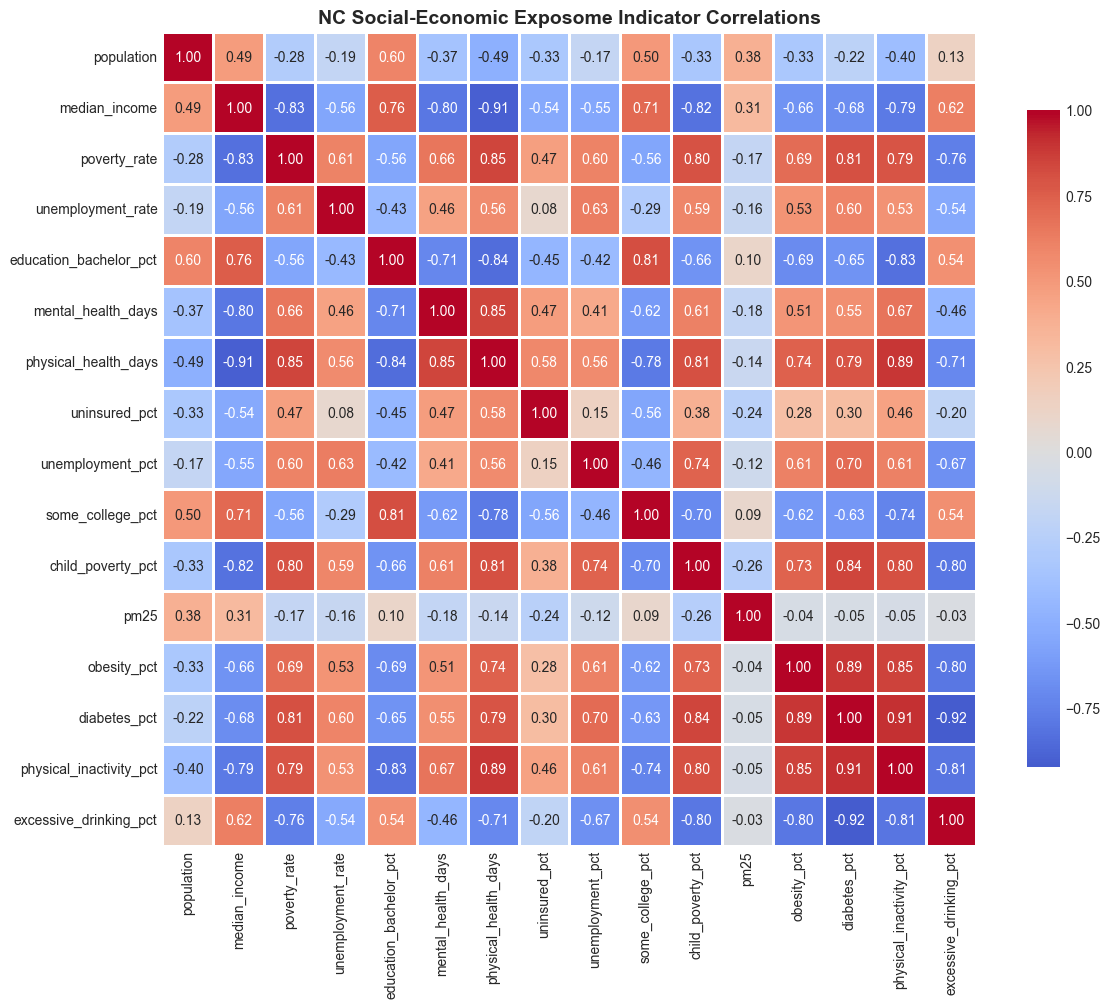

In [16]:
# Visualization 1: Correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('NC Social-Economic Exposome Indicator Correlations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Visualization 2: County comparison radar chart
from math import pi

# Select indicators for radar chart - FIXED: using indicators that exist in the dataset
radar_indicators = ['poverty_rate', 'unemployment_rate', 'obesity_pct', 'diabetes_pct', 'physical_inactivity_pct']
radar_labels = [indicator_metadata[ind][0] for ind in radar_indicators]

# Normalize data to 0-100 scale for better visualization
normalized_data = df_exposome[radar_indicators].copy()
for col in radar_indicators:
    normalized_data[col] = (normalized_data[col] - normalized_data[col].min()) / \
                           (normalized_data[col].max() - normalized_data[col].min()) * 100

# Create radar chart for first 3 counties
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='polar')

angles = [n / len(radar_labels) * 2 * pi for n in range(len(radar_labels))]
angles += angles[:1]

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
for idx in range(3):
    values = normalized_data.iloc[idx].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=df_exposome.iloc[idx]['county'], color=colors[idx])
    ax.fill(angles, values, alpha=0.15, color=colors[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, size=10)
ax.set_ylim(0, 100)
ax.set_title('County Risk Profile Comparison (Normalized)', size=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Visualization 3: Network graph showing indicator relationships (Triple-based)

# Build network from triples
indicator_graph = nx.Graph()

# Add indicators as nodes (FIXED: use dictionary key 'subject' instead of index [0])
indicators = kg.query(predicate='rdf:type', obj='Indicator')
for triple in indicators:
    indicator_id = triple['subject']
    # Get category
    category_triples = kg.query(subject=indicator_id, predicate='category')
    category = category_triples[0]['object'] if category_triples else 'Unknown'
    indicator_graph.add_node(indicator_id, category=category)

# Add correlations as edges (FIXED: use dictionary keys throughout)
correlations = kg.query(predicate='rdf:type', obj='Correlation')
for corr_triple in correlations:
    corr_id = corr_triple['subject']
    
    # Get the two indicators
    ind1_triples = kg.query(subject=corr_id, predicate='indicator1')
    ind2_triples = kg.query(subject=corr_id, predicate='indicator2')
    
    if ind1_triples and ind2_triples:
        ind1 = ind1_triples[0]['object']
        ind2 = ind2_triples[0]['object']
        
        # Get correlation value
        value_triples = kg.query(subject=corr_id, predicate='value')
        corr_value = value_triples[0]['object'] if value_triples else 0
        
        indicator_graph.add_edge(ind1, ind2, 
                                weight=abs(corr_value), 
                                correlation=corr_value)

# Draw network
plt.figure(figsize=(16, 12))
pos = nx.spring_layout(indicator_graph, k=2, iterations=50, seed=42)

# Color nodes by category
node_colors = []
category_colors = {
    'Demographics': '#FF6B6B',
    'Economic': '#4ECDC4',
    'Education': '#45B7D1',
    'Health': '#FFA07A',
    'Environment': '#98D8C8',
    'Access': '#F7DC6F'
}

for node in indicator_graph.nodes():
    category = indicator_graph.nodes[node].get('category', 'Unknown')
    node_colors.append(category_colors.get(category, '#CCCCCC'))

# Draw edges with varying thickness based on correlation strength
edges = indicator_graph.edges()
weights = [indicator_graph[u][v]['weight'] * 3 for u, v in edges]

nx.draw_networkx_edges(indicator_graph, pos, width=weights, alpha=0.3, edge_color='gray')
nx.draw_networkx_nodes(indicator_graph, pos, node_color=node_colors, 
                      node_size=2000, alpha=0.9)
nx.draw_networkx_labels(indicator_graph, pos, font_size=8, font_weight='bold')

# Create legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, label=category) 
                  for category, color in category_colors.items()]
plt.legend(handles=legend_elements, loc='upper left', fontsize=10)

plt.title('NC Exposome Knowledge Graph - Indicator Correlations', 
         fontsize=16, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Visualization 4: County rankings
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

indicators_to_plot = [
    ('median_income', 'Median Income', True),  # True = higher is better
    ('poverty_rate', 'Poverty Rate', False),
    ('healthcare_access', 'Healthcare Access', True),
    ('obesity_pct', 'Obesity Rate', False)
]

for idx, (indicator, title, higher_better) in enumerate(indicators_to_plot):
    ax = axes[idx // 2, idx % 2]
    
    data = df_exposome.sort_values(indicator, ascending=not higher_better)
    colors = ['green' if higher_better else 'red' if i < 3 else 'orange' if i < 7 else 'lightblue' 
             for i in range(len(data))]
    
    ax.barh(data['county'], data[indicator], color=colors, alpha=0.7)
    ax.set_xlabel(indicator_metadata[indicator][1], fontweight='bold')
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('NC County Rankings by Key Indicators', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Export Knowledge Graph

In [18]:
print("Exporting knowledge graph...")

# 1. Export to N-Triples (RDF format)
try:
    filename = kg.export_to_ntriples('nc_exposome_kg.nt')
    print(f"✓ Exported to N-Triples: {filename}")
except Exception as e:
    print(f"⚠ N-Triples export failed: {e}")

# 2. Export to CSV
try:
    df_triples = kg.export_to_csv('nc_exposome_triples.csv')
    print(f"✓ Exported to CSV: nc_exposome_triples.csv ({len(df_triples)} triples)")
except Exception as e:
    print(f"⚠ CSV export failed: {e}")

# 3. Export data table
try:
    df_exposome.to_csv('nc_exposome_data.csv', index=False)
    print(f"✓ Exported data table: nc_exposome_data.csv")
except Exception as e:
    print(f"⚠ Data export failed: {e}")

# 4. Show sample triples (FIXED: triples are dictionaries, not tuples)
print(f"\n📊 Sample Triples (first 20 out of {len(kg.triples)}):")
print("-" * 80)
for i, triple in enumerate(kg.triples[:20], 1):
    s = triple['subject']
    p = triple['predicate']
    o = triple['object']
    # Truncate long objects
    o_str = str(o)
    if len(o_str) > 50:
        o_str = o_str[:47] + "..."
    print(f"{i:2d}. ({s}, {p}, {o_str})")

print("\n✓ Export complete!")

Exporting knowledge graph...
✓ Exported to N-Triples: nc_exposome_kg.nt
✓ Exported to CSV: nc_exposome_triples.csv (13183 triples)
✓ Exported data table: nc_exposome_data.csv

📊 Sample Triples (first 20 out of 13183):
--------------------------------------------------------------------------------
 1. (37001, rdf:type, Location)
 2. (37001, locationType, county)
 3. (37001, name, Alamance)
 4. (37001, state, North Carolina)
 5. (37001, population, 171779)
 6. (37003, rdf:type, Location)
 7. (37003, locationType, county)
 8. (37003, name, Alexander)
 9. (37003, state, North Carolina)
10. (37003, population, 36505)
11. (37005, rdf:type, Location)
12. (37005, locationType, county)
13. (37005, name, Alleghany)
14. (37005, state, North Carolina)
15. (37005, population, 10989)
16. (37007, rdf:type, Location)
17. (37007, locationType, county)
18. (37007, name, Anson)
19. (37007, state, North Carolina)
20. (37007, population, 22200)

✓ Export complete!


## 10. Advanced Analytics

Original dataset: 100 counties
Missing values per feature:
  pm25: 1 missing (1.0%)

After removing rows with missing values: 99 counties

✓ Clustering complete for 99 counties


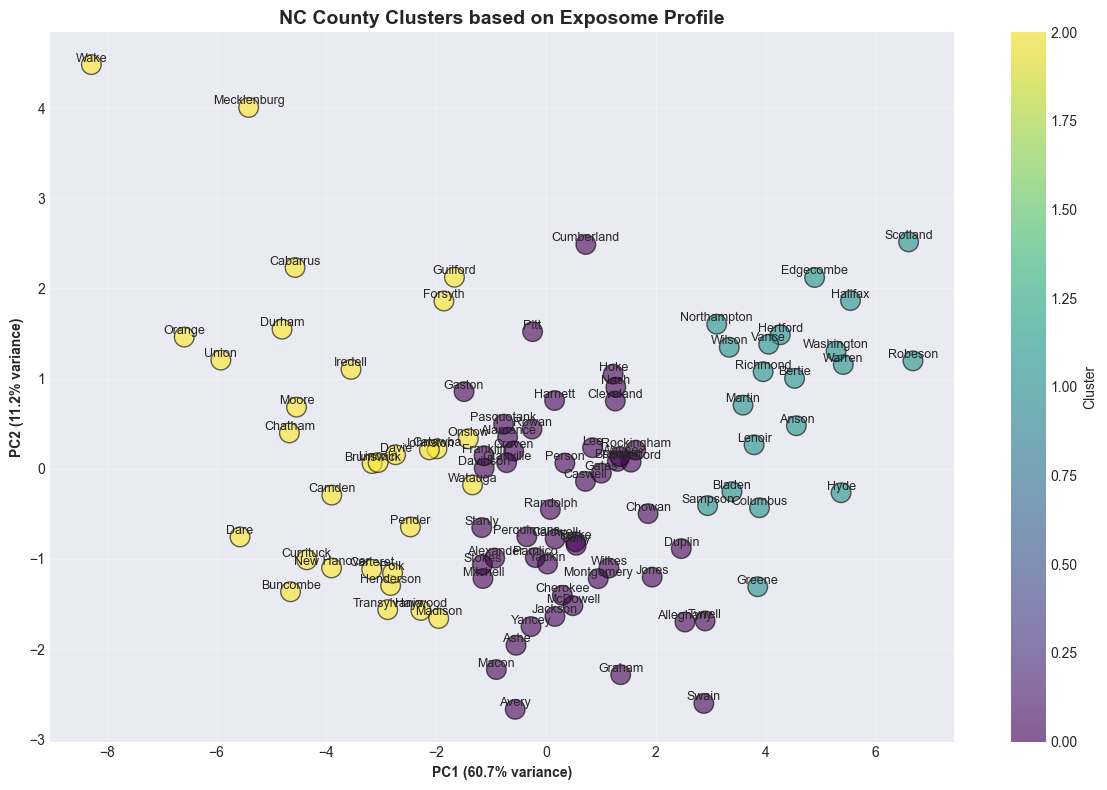


County Clusters:
  Cluster 0 (49 counties): Alamance, Alexander, Alleghany, Ashe, Avery, Beaufort, Burke, Caldwell, Caswell, Cherokee
    ... and 39 more
  Cluster 1 (20 counties): Anson, Bertie, Bladen, Columbus, Edgecombe, Greene, Halifax, Hertford, Hyde, Lenoir
    ... and 10 more
  Cluster 2 (30 counties): Brunswick, Buncombe, Cabarrus, Camden, Carteret, Catawba, Chatham, Currituck, Dare, Davie
    ... and 20 more


In [20]:
# Identify clusters of counties with similar profiles
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Prepare data for clustering
features = numeric_cols
X = df_exposome[features].copy()

# Handle missing values - drop rows with any NaN in the features used for clustering
# First, let's see how much data we have
print(f"Original dataset: {len(X)} counties")
print(f"Missing values per feature:")
for col in features:
    missing = X[col].isna().sum()
    if missing > 0:
        print(f"  {col}: {missing} missing ({missing/len(X)*100:.1f}%)")

# Create a clean dataset by dropping rows with NaN values
X_clean = X.dropna()
print(f"\nAfter removing rows with missing values: {len(X_clean)} counties")

# Get the indices of counties with complete data
valid_indices = X_clean.index
df_exposome_clean = df_exposome.loc[valid_indices].copy()

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

# Perform clustering
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
df_exposome_clean['cluster'] = kmeans.fit_predict(X_scaled)

# Add cluster assignments back to the main dataframe (NaN for counties without complete data)
df_exposome['cluster'] = df_exposome_clean['cluster']

print(f"\n✓ Clustering complete for {len(df_exposome_clean)} counties")

# Visualize clusters
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_exposome_clean['cluster'], 
                     cmap='viridis', s=200, alpha=0.6, edgecolors='black')

# Add county labels
for i, county in enumerate(df_exposome_clean['county']):
    plt.annotate(county, (X_pca[i, 0], X_pca[i, 1]), 
                fontsize=9, ha='center', va='bottom')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontweight='bold')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontweight='bold')
plt.title('NC County Clusters based on Exposome Profile', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Cluster')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nCounty Clusters:")
for cluster_id in range(n_clusters):
    counties = df_exposome_clean[df_exposome_clean['cluster'] == cluster_id]['county'].tolist()
    print(f"  Cluster {cluster_id} ({len(counties)} counties): {', '.join(counties[:10])}")
    if len(counties) > 10:
        print(f"    ... and {len(counties) - 10} more")

In [22]:
# Summary statistics by cluster
# Use only columns that exist in the dataframe
cluster_cols = ['poverty_rate', 'median_income', 'obesity_pct']

# Add other available health indicators
if 'diabetes_pct' in df_exposome.columns:
    cluster_cols.append('diabetes_pct')
if 'uninsured_pct' in df_exposome.columns:
    cluster_cols.append('uninsured_pct')

cluster_summary = df_exposome.groupby('cluster')[cluster_cols].mean()
print("\nCluster Characteristics:")
cluster_summary


Cluster Characteristics:


,poverty_rate,median_income,obesity_pct,diabetes_pct,uninsured_pct
cluster,,,,,
0.0,15.580037,55706.040816,36.008163,11.142857,12.988464
1.0,22.350843,44108.350000,40.690000,13.945000,13.405772
2.0,11.198579,71910.600000,32.026667,9.556667,10.953534
